<a href="https://colab.research.google.com/github/Valentinekrafft/Machinelearningproject/blob/main/accord_de_paris_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

voici les liens des deux dataset a telecharger:
- https://www.kaggle.com/datasets/danielrpdias/co2-and-greenhouse-gas-emissions
- https://archive.ourworldindata.org/20250717-120101/grapher/renewable-share-energy.html?tab=table&time=2000..2022#sources-and-processing


In [ ]:
import numpy as np
import pandas as pd
from google.colab import files
import io

In [ ]:
uploaded = files.upload("owid-co2-data.csv")
filename = list(uploaded.keys())[0]
df= pd.read_csv(io.BytesIO(uploaded[filename]))

# View the first few rows
df.head()

Saving owid-co2-data.csv to owid-co2-data.csv/owid-co2-data (1).csv


,iso_code,country,year,co2,consumption_co2,co2_growth_prct,co2_growth_abs,trade_co2,co2_per_capita,consumption_co2_per_capita,...,ghg_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp
0,AFG,Afghanistan,1949,0.015,NaN,NaN,NaN,NaN,0.002,NaN,...,NaN,NaN,NaN,NaN,NaN,7624058.0,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,1950,0.084,NaN,475.0,0.070,NaN,0.011,NaN,...,NaN,NaN,NaN,NaN,NaN,7752117.0,9.421400e+09,NaN,NaN,NaN
2,AFG,Afghanistan,1951,0.092,NaN,8.7,0.007,NaN,0.012,NaN,...,NaN,NaN,NaN,NaN,NaN,7840151.0,9.692280e+09,NaN,NaN,NaN
3,AFG,Afghanistan,1952,0.092,NaN,0.0,0.000,NaN,0.012,NaN,...,NaN,NaN,NaN,NaN,NaN,7935996.0,1.001732e+10,NaN,NaN,NaN
4,AFG,Afghanistan,1953,0.106,NaN,16.0,0.015,NaN,0.013,NaN,...,NaN,NaN,NaN,NaN,NaN,8039684.0,1.063052e+10,NaN,NaN,NaN


In [ ]:
display(df.columns)
display(df.info())

Index(['iso_code', 'country', 'year', 'co2', 'consumption_co2',
       'co2_growth_prct', 'co2_growth_abs', 'trade_co2', 'co2_per_capita',
       'consumption_co2_per_capita', 'share_global_co2', 'cumulative_co2',
       'share_global_cumulative_co2', 'co2_per_gdp', 'consumption_co2_per_gdp',
       'co2_per_unit_energy', 'coal_co2', 'cement_co2', 'flaring_co2',
       'gas_co2', 'oil_co2', 'other_industry_co2', 'cement_co2_per_capita',
       'coal_co2_per_capita', 'flaring_co2_per_capita', 'gas_co2_per_capita',
       'oil_co2_per_capita', 'other_co2_per_capita', 'trade_co2_share',
       'share_global_cement_co2', 'share_global_coal_co2',
       'share_global_flaring_co2', 'share_global_gas_co2',
       'share_global_oil_co2', 'share_global_other_co2',
       'cumulative_cement_co2', 'cumulative_coal_co2',
       'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_oil_co2',
       'cumulative_other_co2', 'share_global_cumulative_cement_co2',
       'share_global_cumulative_c

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25204 entries, 0 to 25203
Data columns (total 58 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   iso_code                             21948 non-null  object 
 1   country                              25204 non-null  object 
 2   year                                 25204 non-null  int64  
 3   co2                                  23949 non-null  float64
 4   consumption_co2                      3976 non-null   float64
 5   co2_growth_prct                      24931 non-null  float64
 6   co2_growth_abs                       23585 non-null  float64
 7   trade_co2                            3976 non-null   float64
 8   co2_per_capita                       23307 non-null  float64
 9   consumption_co2_per_capita           3976 non-null   float64
 10  share_global_co2                     23949 non-null  float64
 11  cumulative_co2              

None

In [ ]:
#filtrer les pays de l'OCDE
oecd_countries = [
    "France","Germany","United States","Japan","Canada","Australia",
    "United Kingdom","Italy","Spain","Netherlands","Belgium",
    "Switzerland","Sweden","Norway","Denmark","Finland",
    "Austria","Ireland","Portugal","Greece","New Zealand",
    "South Korea","Czechia","Poland","Hungary","Slovakia",
    "Slovenia","Estonia","Latvia","Lithuania","Luxembourg",
    "Iceland","Israel","Chile","Mexico","Turkey","Colombia","Costa Rica"
]

df = df[df["country"].isin(oecd_countries)]

In [ ]:
#filtrer les années
df = df[(df["year"] >= 2000) & (df["year"] <= 2020)]
df["year"].min(), df["year"].max()

(2000, 2020)

In [ ]:
df["country"].nunique()

38

In [ ]:
cols = [
    "country",
    "year",
    "co2",
    "co2_per_capita",
    "co2_per_gdp",
    "gdp",
    "population",
    "trade_co2",
    "consumption_co2",
    "primary_energy_consumption",
    "energy_per_capita",
    "energy_per_gdp",
    "coal_co2",
    "oil_co2",
    "gas_co2"
]

df = df[cols]

In [ ]:
df.shape

(798, 15)

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df = df.drop(columns=["energy_per_gdp"])

In [ ]:
df.duplicated(subset=["country","year"]).sum()

np.int64(0)

ajouter part des éneriges renouvlable

In [ ]:
uploaded = files.upload("renewable-share-energy.csv")
filename = list(uploaded.keys())[0]
df1= pd.read_csv(io.BytesIO(uploaded[filename]))

Saving renewable-share-energy.csv to renewable-share-energy.csv/renewable-share-energy (2).csv


In [ ]:
df1.head()

,Entity,Year,Renewables (% equivalent primary energy)
0,Africa,1965,5.419266
1,Africa,1966,5.772398
2,Africa,1967,5.963763
3,Africa,1968,6.605470
4,Africa,1969,7.505726


In [ ]:
df1 = df1.rename(columns={
    "Entity": "country",
    "Year": "year",
    "Renewables (% equivalent primary energy)": "renewable_share"
})
df1 = df1[(df1["year"] >= 2000) & (df1["year"] <= 2020)]

In [ ]:
set(df["country"]) - set(df1["country"])

{'Costa Rica'}

In [ ]:
df1 = df1[df1["country"].isin(df["country"])]

In [ ]:
df_good = df.merge(df1, on=["country","year"], how="left")

In [ ]:
df_good.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 798 entries, 0 to 797
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     798 non-null    object 
 1   year                        798 non-null    int64  
 2   co2                         798 non-null    float64
 3   co2_per_capita              798 non-null    float64
 4   co2_per_gdp                 722 non-null    float64
 5   gdp                         722 non-null    float64
 6   population                  798 non-null    float64
 7   trade_co2                   737 non-null    float64
 8   consumption_co2             737 non-null    float64
 9   primary_energy_consumption  757 non-null    float64
 10  energy_per_capita           757 non-null    float64
 11  coal_co2                    794 non-null    float64
 12  oil_co2                     798 non-null    float64
 13  gas_co2                     777 non

remplire les NAN et que deux pays supprimé

In [ ]:
df_good = df_good.sort_values(["country", "year"])

df_good = df_good.groupby("country").apply(
    lambda x: x.interpolate(method="linear")
)

/tmp/ipykernel_311/861228944.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method="linear")
/tmp/ipykernel_311/861228944.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method="linear")
/tmp/ipykernel_311/861228944.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method="linear")
/tmp/ipykernel_311/861228944.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda x: x.interpolate(method="linear")
/tmp/ipy

In [ ]:
df_good = df_good.reset_index(drop=True)

In [ ]:
df_good = df_good.groupby("country").apply(
    lambda x: x.ffill().bfill()
).reset_index(drop=True)

/tmp/ipykernel_311/138868880.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_good = df_good.groupby("country").apply(


In [ ]:
df_good = df_good[df_good["country"] != "Costa Rica"]

In [ ]:
df_good = df_good[df_good["country"] != "Iceland"]

In [ ]:
df_good.isna().sum()

,0
country,0
year,0
co2,0
co2_per_capita,0
co2_per_gdp,0
gdp,0
population,0
trade_co2,0
consumption_co2,0
primary_energy_consumption,0


In [ ]:
# costa rica et Iceland drop (36 au lieu de 38 pays--> ok)
df_good.shape

(756, 15)

ajout de variable clef:

In [ ]:
# carbonne intensity: Mesure combien de CO₂ est émis pour produire du PIB.
df_good["carbon_intensity"] = df_good["co2"] / df_good["gdp"]

In [ ]:
# energy intensity: Mesure combien d’énergie est nécessaire pour produire du PIB.
df_good["energy_intensity"] = df_good["primary_energy_consumption"] / df_good["gdp"]

In [ ]:
# carbonne per energy: Mesure la propreté du mix énergétique.
df_good["carbon_per_energy"] = df_good["co2"] / df_good["primary_energy_consumption"]

In [ ]:
# gdp per capita...
df_good["gdp_per_capita"] = df_good["gdp"] / df_good["population"]

In [ ]:
df_good.head()

,country,year,co2,co2_per_capita,co2_per_gdp,gdp,population,trade_co2,consumption_co2,primary_energy_consumption,energy_per_capita,coal_co2,oil_co2,gas_co2,renewable_share,carbon_intensity,energy_intensity,carbon_per_energy,gdp_per_capita
0,Australia,2000,351.820,18.525,0.508,6.918867e+11,18991434.0,-60.477,291.343,1313.507,69164.691,186.942,102.976,46.885,3.764508,5.084937e-10,1.898442e-09,0.267848,36431.511779
1,Australia,2001,360.455,18.779,0.505,7.136258e+11,19194676.0,-62.273,298.181,1325.592,69059.245,191.835,103.536,49.769,3.655366,5.051037e-10,1.857545e-09,0.271920,37178.317832
2,Australia,2002,367.113,18.922,0.492,7.466835e+11,19401366.0,-46.357,320.756,1345.272,69340.366,194.077,106.127,51.353,3.710854,4.916581e-10,1.801663e-09,0.272891,38486.130339
3,Australia,2003,373.233,19.019,0.482,7.738686e+11,19624163.0,-38.983,334.250,1365.545,69585.462,197.462,110.743,50.233,3.796507,4.822951e-10,1.764570e-09,0.273322,39434.476404
4,Australia,2004,386.766,19.455,0.478,8.094197e+11,19879654.0,-39.372,347.394,1410.881,70969.860,204.293,114.938,53.059,3.829067,4.778312e-10,1.743077e-09,0.274131,40715.987057


EDA

In [ ]:
import matplotlib.pyplot as plt

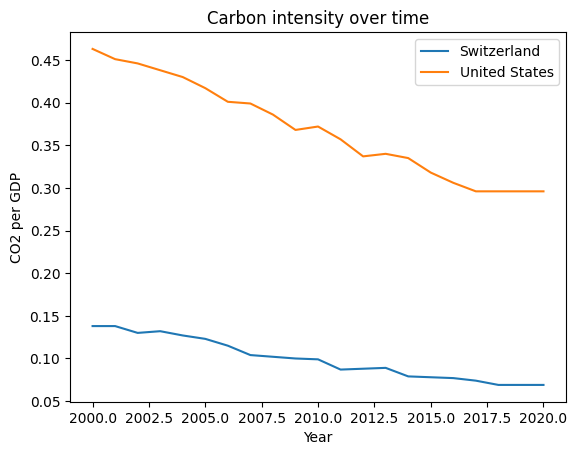

In [ ]:
# évolution de l'intensité (CH et USA)



# filtrer les deux pays
df_plot = df_good[df_good["country"].isin(["Switzerland", "United States"])]

# tracer
for country in df_plot["country"].unique():
    subset = df_plot[df_plot["country"] == country]
    plt.plot(subset["year"], subset["co2_per_gdp"], label=country)

plt.xlabel("Year")
plt.ylabel("CO2 per GDP")
plt.title("Carbon intensity over time")
plt.legend()
plt.show()